In [ ]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Semua library berhasil diimport!")

# Mini Project Neural Network
## Heart Disease Classification menggunakan MLPClassifier

Nama: [Amanda Damayanti]  
NIM: [202432027]  
Kelas: [Pembelajaran Mesin A]  

Dataset: Heart Disease UCI  
Sumber: GitHub (sharmaroshan/Heart-UCI-Dataset)  
Jumlah baris: 303  
Jumlah fitur: 13 fitur + 1 target  
Task: Klasifikasi biner — memprediksi apakah pasien mengidap penyakit jantung (1) atau tidak (0)

In [4]:
# Load dataset langsung dari GitHub tanpa perlu download manual
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

# Tampilkan shape dan 5 baris pertama
print("Shape dataset:", df.shape)
df.head()

Shape dataset: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# Statistik deskriptif untuk semua kolom
# Menampilkan mean, std, min, max, quartile tiap fitur
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
# Cek missing value di setiap kolom
print("Missing value per kolom:")
print(df.isnull().sum())
print("\nTotal missing value:", df.isnull().sum().sum())

Missing value per kolom:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing value: 0


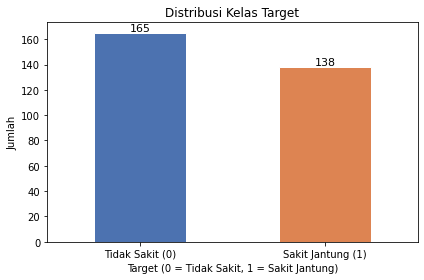


Distribusi kelas:
1    165
0    138
Name: target, dtype: int64


In [7]:
# Visualisasi distribusi kelas target
# 0 = tidak sakit jantung, 1 = sakit jantung
plt.figure(figsize=(6, 4))
ax = df['target'].value_counts().plot(
    kind='bar',
    color=['#4C72B0', '#DD8452'],
    edgecolor='white'
)
ax.set_title('Distribusi Kelas Target')
ax.set_xlabel('Target (0 = Tidak Sakit, 1 = Sakit Jantung)')
ax.set_ylabel('Jumlah')
ax.set_xticklabels(['Tidak Sakit (0)', 'Sakit Jantung (1)'], rotation=0)

# Tambahkan angka di atas tiap bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

print("\nDistribusi kelas:")
print(df['target'].value_counts())

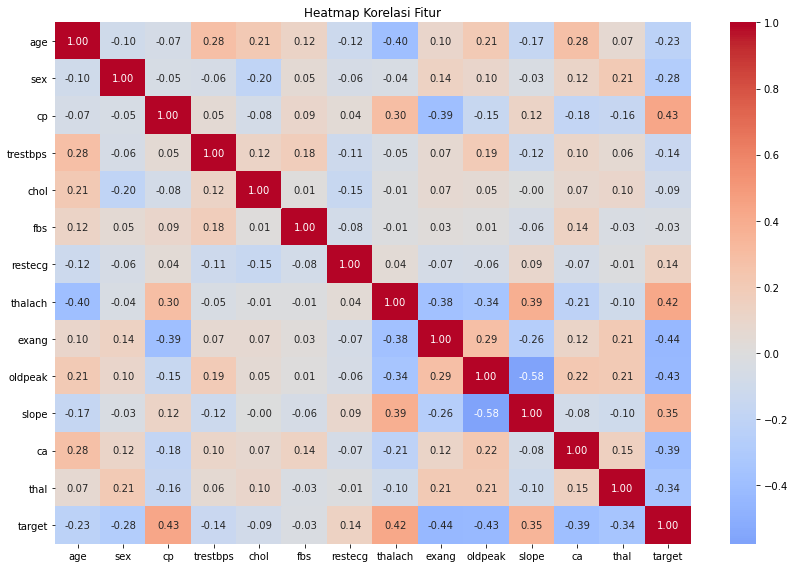

In [8]:
# Heatmap korelasi antar fitur
# Berguna untuk melihat fitur mana yang paling berpengaruh terhadap target
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.show()

## Preprocessing
Tahap persiapan data sebelum dimasukkan ke model:
1. Memisahkan fitur (X) dan target (y)
2. Split data train dan test (80:20)
3. Feature Scaling menggunakan `StandardScaler` — wajib untuk Neural Network karena MLP sangat sensitif terhadap skala data

In [9]:
# Pisahkan fitur (X) dan target (y)
X = df.drop('target', axis=1)  # semua kolom kecuali target
y = df['target']                # kolom target saja

print("Shape X (fitur):", X.shape)
print("Shape y (target):", y.shape)
print("\nNama fitur:", list(X.columns))

Shape X (fitur): (303, 13)
Shape y (target): (303,)

Nama fitur: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [10]:
# Split data menjadi training (80%) dan testing (20%)
# stratify=y memastikan proporsi kelas seimbang di kedua set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran data training:", X_train.shape)
print("Ukuran data testing:", X_test.shape)

Ukuran data training: (242, 13)
Ukuran data testing: (61, 13)


In [11]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

# fit_transform pada data training, transform saja pada data testing
# Hindari fit pada test set untuk mencegah data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling selesai!")
print("Contoh nilai setelah scaling (3 sampel pertama, 3 fitur pertama):")
print(X_train_scaled[:3, :3])

Scaling selesai!
Contoh nilai setelah scaling (3 sampel pertama, 3 fitur pertama):
[[ 1.61047991 -1.46385011  2.04442042]
 [ 1.28205058  0.68313005  0.05747367]
 [ 0.0778097  -1.46385011 -0.93599971]]


## Membangun Model Neural Network
Menggunakan `MLPClassifier` dari scikit-learn dengan arsitektur:
- Hidden layers: 2 layer → 100 neuron dan 50 neuron
- Fungsi aktivasi: `relu`
- Optimizer: `adam`
- Maksimum iterasi: 500

In [12]:
# Bangun model MLP (Multi-Layer Perceptron)
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # 2 hidden layer: 100 neuron lalu 50 neuron
    activation='relu',             # fungsi aktivasi ReLU
    solver='adam',                 # optimizer Adam
    max_iter=500,                  # maksimum iterasi training
    random_state=42
)

# Training model dengan data training yang sudah di-scaling
mlp.fit(X_train_scaled, y_train)

print("Training selesai!")
print(f"Jumlah iterasi yang dilakukan: {mlp.n_iter_}")
print(f"Loss akhir: {mlp.loss_curve_[-1]:.4f}")

Training selesai!
Jumlah iterasi yang dilakukan: 304
Loss akhir: 0.0068


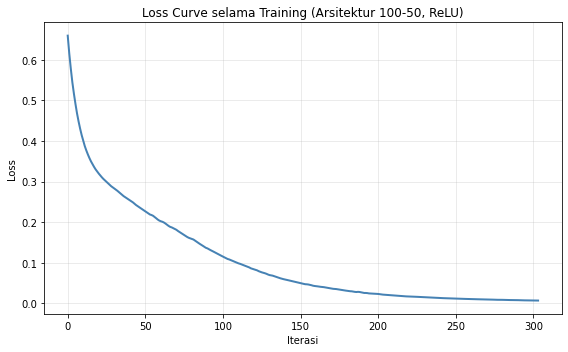

In [13]:
# Plot loss curve selama proses training
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, color='steelblue', linewidth=2)
plt.title('Loss Curve selama Training (Arsitektur 100-50, ReLU)')
plt.xlabel('Iterasi')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluasi Model
Mengevaluasi performa model menggunakan:
- **Accuracy** — persentase prediksi yang benar
- **Classification Report** — precision, recall, f1-score per kelas
- **Confusion Matrix** — visualisasi prediksi benar vs salah

In [14]:
# Prediksi pada data testing
y_pred = mlp.predict(X_test_scaled)

# Hitung accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print()

# Classification report: precision, recall, f1-score
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Tidak Sakit', 'Sakit Jantung']))

Accuracy: 0.7705 (77.05%)

Classification Report:
               precision    recall  f1-score   support

  Tidak Sakit       0.77      0.71      0.74        28
Sakit Jantung       0.77      0.82      0.79        33

     accuracy                           0.77        61
    macro avg       0.77      0.77      0.77        61
 weighted avg       0.77      0.77      0.77        61



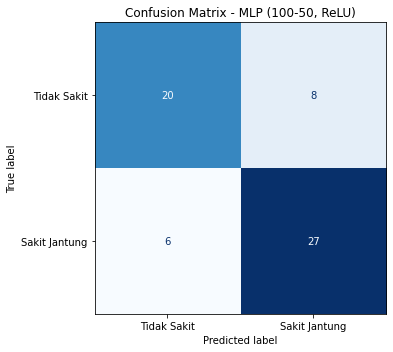

In [15]:
# Visualisasi confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Tidak Sakit', 'Sakit Jantung']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - MLP (100-50, ReLU)')
plt.tight_layout()
plt.show()

## Perbandingan Arsitektur & Fungsi Aktivasi
Membandingkan 3 konfigurasi model berbeda untuk melihat pengaruh arsitektur 
dan fungsi aktivasi terhadap performa model.

In [ ]:
# Definisikan konfigurasi yang akan dibandingkan
configs = [
    {'hidden_layer_sizes': (100, 50),      'activation': 'relu', 'label': '(100-50) ReLU'},
    {'hidden_layer_sizes': (100, 50),      'activation': 'tanh', 'label': '(100-50) Tanh'},
    {'hidden_layer_sizes': (200, 100, 50), 'activation': 'relu', 'label': '(200-100-50) ReLU'},
]

results = []
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, cfg in enumerate(configs):
    # Bangun dan training tiap model
    model = MLPClassifier(
        hidden_layer_sizes=cfg['hidden_layer_sizes'],
        activation=cfg['activation'],
        solver='adam',
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    
    # Evaluasi tiap model
    y_pred_cfg = model.predict(X_test_scaled)
    acc_cfg = accuracy_score(y_test, y_pred_cfg)
    results.append({'Arsitektur': cfg['label'], 'Accuracy': f"{acc_cfg*100:.2f}%"})
    
    # Plot loss curve masing-masing arsitektur
    axes[i].plot(model.loss_curve_, linewidth=2)
    axes[i].set_title(cfg['label'], fontsize=10)
    axes[i].set_xlabel('Iterasi')
    axes[i].set_ylabel('Loss')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Perbandingan Loss Curve Antar Arsitektur', fontsize=13)
plt.tight_layout()
plt.show()

# Tampilkan tabel perbandingan accuracy
df_results = pd.DataFrame(results)
print("\nPerbandingan Accuracy:")
print(df_results.to_string(index=False))

## Analisis & Kesimpulan

### Analisis Loss Curve
- Loss curve model utama (100-50, ReLU) menunjukkan penurunan yang konsisten 
  dan konvergen di sekitar iterasi ke-304 dari maksimum 500 iterasi.
- Hal ini menandakan model berhasil belajar dari data training dengan baik.

### Analisis Performa Model
- Accuracy model utama (100-50, ReLU): **77.05%**
- Recall pada kelas "Sakit Jantung" mencapai **0.82** artinya dari 33 pasien 
  yang benar-benar sakit, model berhasil mendeteksi 82% nya.
- Dalam konteks medis, recall lebih diprioritaskan karena false negative 
  (pasien sakit dikira sehat) jauh lebih berbahaya dibanding false positive.

### Overfitting / Underfitting / Good Fit?
- Model menunjukkan kondisi **good fit** loss curve turun stabil dan 
  accuracy di angka 77% cukup memadai untuk dataset berukuran 303 baris.
- Tidak ada indikasi overfitting karena loss tidak naik kembali di akhir iterasi.

### Perbandingan Arsitektur (Bonus)
- **(100-50) Tanh** menghasilkan accuracy tertinggi sebesar **78.69%**
- **(200-100-50) ReLU** tidak memberikan peningkatan meskipun arsitekturnya 
  lebih besar bahkan belum konvergen dalam 500 iterasi, menandakan 
  model terlalu kompleks untuk dataset sekecil ini.
- Fungsi aktivasi **Tanh sedikit unggul** dibanding ReLU pada dataset ini.

### Kesimpulan
Neural Network dengan MLPClassifier berhasil mengklasifikasikan penyakit jantung 
dengan accuracy terbaik **78.69%** menggunakan arsitektur (100-50) dan aktivasi Tanh.
Dataset Heart Disease UCI terbukti cocok untuk klasifikasi biner menggunakan Neural Network,
dengan catatan bahwa ukuran dataset yang relatif kecil (303 baris) membatasi 
potensi peningkatan performa meskipun arsitektur diperbesar.